In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [2]:
from sysstrat.data import load_simple_price_csv
from sysstrat.core import Asset, Capital, FixedRiskSizer
from sysstrat.engine import BacktestRunner
from sysstrat.strategies import BuyAndHoldStrategy
from sysstrat.visualization import plot_backtest_results, print_report_comparison

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv")
MCFTR = Asset(ticker= 'MCFTR', price_data=data, commission_rate=0.0004, slippage_rate=0.001)

In [4]:
# ==========================================
# 1. Configuration
# ==========================================
INITIAL_CAPITAL = 100_000
VOLATILITY_WINDOW = 252
MAX_LEVERAGE = 1.0

In [5]:
# ==========================================
# 2. Setup Sizers and Runners
# ==========================================
# Conservative: 20% Target Risk
sizer_conservative = FixedRiskSizer(
    vol_method="sma",
    volatility_window=VOLATILITY_WINDOW, 
    risk_target=0.1, 
    max_leverage=MAX_LEVERAGE
)

# Risky: 40% Target Risk
sizer_risky = FixedRiskSizer(
    vol_method="sma",
    volatility_window=VOLATILITY_WINDOW, 
    risk_target=0.2, 
    max_leverage=MAX_LEVERAGE
)

capital = Capital(initial_capital=INITIAL_CAPITAL)

In [6]:
# Initialize Runners
runner_conservative = BacktestRunner(capital=capital, asset=MCFTR, sizer=sizer_conservative)
runner_risky = BacktestRunner(capital=capital, asset=MCFTR, sizer=sizer_risky)

# Execute
report_fixed = runner_conservative.run(BuyAndHoldStrategy())
report_risky = runner_risky.run(BuyAndHoldStrategy())

c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\visualization\plotter.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


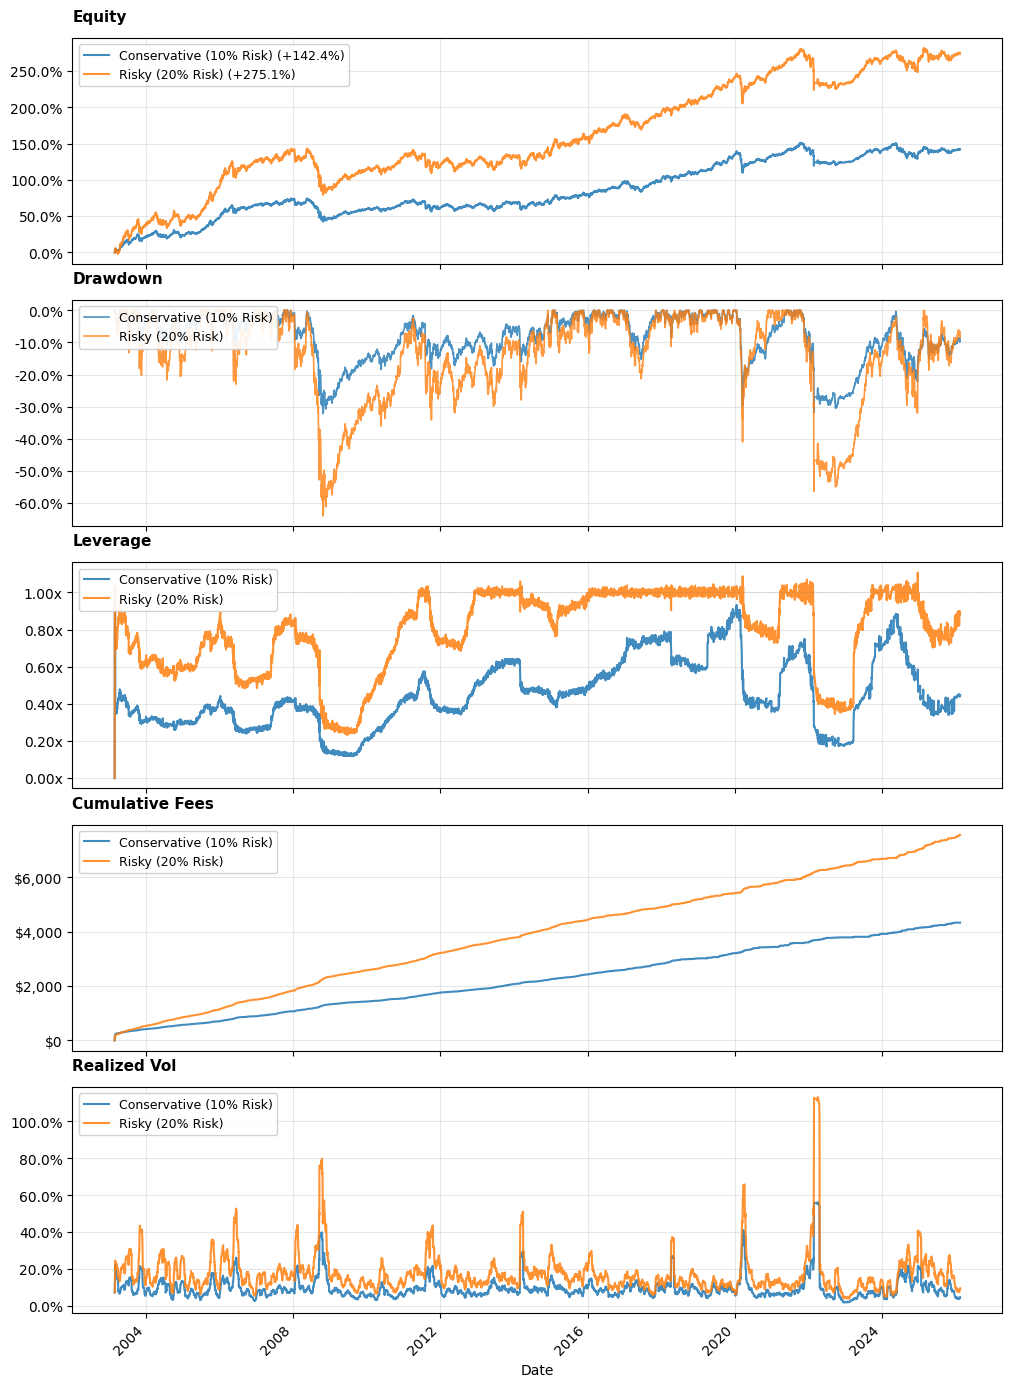

In [7]:
plot_backtest_results(
    results={
        "Conservative (10% Risk)": report_fixed.result, 
        "Risky (20% Risk)": report_risky.result
    },
    plot_pct=True,
    figsize_base=(12, 3)
)

In [8]:
print_report_comparison(
    title="Vol-Adjusted B&H Comparison",
    reports={
        "Conservative (20%)": report_fixed,
        "Risky (40%)": report_risky
    }
)


──────────────────────┬────────────────────┬─────────────┐
│             Vol-Adjusted B&H Comparison             │
├──────────────────────┼────────────────────┼─────────────┤
│Metric                │ Conservative (20%) │ Risky (40%) │
├──────────────────────┼────────────────────┼─────────────┤
│  Returns & Performance                              │
├──────────────────────┼────────────────────┼─────────────┤
│Total Return %        │           +142.40% │    +275.09% │
│CAGR %                │             +6.25% │     +12.07% │
├──────────────────────┼────────────────────┼─────────────┤
│ ⚠️ Risk & Volatility                                │
├──────────────────────┼────────────────────┼─────────────┤
│Annual Vol %          │            +11.05% │     +20.31% │
│Max Drawdown %        │            -32.23% │     -64.11% │
│Avg Drawdown %        │             -2.12% │      -3.70% │
├──────────────────────┼────────────────────┼─────────────┤
│ 🎯 Risk-Adjusted Returns                           